# 1. Imports

In [2]:
import os
import cv2 as cv
import numpy as np
from mtcnn.mtcnn import MTCNN
from PIL import Image
from keras_facenet import FaceNet
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

# 2. Global config

In [3]:
TARGET_SIZE = (160, 160) # FaceNet image input size
ALLOWED_EXT = (".jpg", ".jpeg", ".png", ".webp", ".bmp")
SAVED_MODEL_PATH = "svm_face_model.pkl"

# 3. Image Load (class) + Clean + Convert + Crop

In [4]:
class FACELOADING:
    def __init__(self, directory, target_size=TARGET_SIZE):
        self.directory = directory
        self.target_size = target_size
        self.detector = MTCNN()  # Face detector
        self.X = []  # Save face image
        self.Y = [] # Label(Persons Name) saving

    # 1. Reading and converting images
    def read_and_convert(self, filepath):
        try:
            img = Image.open(filepath).convert("RGB")
        except Exception as e:
            print(f"Bad image removed: {filepath} ({e})")
            try: os.remove(filepath)
            except: pass
            return None, None

        # 1.1 Format conversion
        ext = os.path.splitext(filepath)[1].lower()
        if ext not in (".jpg", ".jpeg"):
            new_path = os.path.splitext(filepath)[0] + ".jpg"
            try:
                img.save(new_path, "JPEG", quality=95)
                if new_path != filepath:
                    try: os.remove(filepath)
                    except: pass
                filepath = new_path
            except:
                return None, None

        img_np = np.array(img)
        img_bgr = cv.cvtColor(img_np, cv.COLOR_RGB2BGR)
        return img_bgr, filepath

    # 2. Extracting faces from images
    def extract_face(self, filepath):
        img_bgr, final_path = self.read_and_convert(filepath)
        if img_bgr is None:
            return None

        # 2.1 Convert to RGB for MTCNN
        img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
        try:
            faces = self.detector.detect_faces(img_rgb)
        except:
            return None

        if not faces:
            print(f"No face found: {final_path}")
            return None

        # 2.2 First face cropping
        x, y, w, h = faces[0]['box']
        x, y = abs(x), abs(y)
        x2, y2 = x + w, y + h
        face = img_rgb[y:y2, x:x2]

        if face.size == 0:
            return None

        # 2.3 Resize to target size
        face_resized = cv.resize(face, self.target_size)
        return face_resized

    # 3. Loading all faces of a class
    def load_faces_from_class(self, class_dir):
        faces = []
        for fname in os.listdir(class_dir):
            fullpath = os.path.join(class_dir, fname)
            if not os.path.isfile(fullpath):
                continue
            face = self.extract_face(fullpath)
            if face is not None:
                faces.append(face)
        return faces

    # 4. Loading faces of all classes
    def load_classes(self):
        for cls in sorted(os.listdir(self.directory)):
            cls_path = os.path.join(self.directory, cls)

            if not os.path.isdir(cls_path):
                continue

            faces = self.load_faces_from_class(cls_path)
            self.X.extend(faces)
            self.Y.extend([cls] * len(faces))

            print(f"Loaded {len(faces)} faces for class '{cls}'")

        return np.asarray(self.X), np.asarray(self.Y)

# 4. Visualize Loaded Sample Faces

In [5]:
# Showing samples of loaded few faces
def plot_samples(images, limit=12):
    import math
    if len(images) == 0:
        print("No images to show.")
        return
    
    n = min(limit, len(images))
    rows = math.ceil(n / 4)
    
    plt.figure(figsize=(10, 8))
    for i in range(n):
        plt.subplot(rows, 4, i+1)
        plt.imshow(images[i])
        plt.axis("off")
    plt.show()

# 5. Embedding using FaceNet

In [6]:
embedder = FaceNet()

def get_embedding(face_img):
    img = face_img.astype("float32")
    img = np.expand_dims(img, axis=0)
    emb = embedder.embeddings(img)
    return emb[0]

2025-11-22 10:13:04.888774: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


# 6. Train SVM + Evaluate

In [7]:
def train_svm_with_metrics(EMBEDDED_X, Y_labels):
    encoder = LabelEncoder()
    Y_enc = encoder.fit_transform(Y_labels)

    X_train, X_test, Y_train, Y_test = train_test_split(
        EMBEDDED_X, Y_enc, test_size=0.25, random_state=17, stratify=Y_enc
    )

    model = SVC(kernel="linear", probability=True)
    model.fit(X_train, Y_train)

    Y_train_pred = model.predict(X_train)
    Y_pred = model.predict(X_test)

    # Added Train & Test Accuracy
    print(f"Train Accuracy : {accuracy_score(Y_train, Y_train_pred):.4f}")
    print(f"Test Accuracy  : {accuracy_score(Y_test, Y_pred):.4f}")

    print("\nClassification Report:")
    print(classification_report(Y_test, Y_pred, target_names=encoder.classes_))

    cm = confusion_matrix(Y_test, Y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=encoder.classes_,
                yticklabels=encoder.classes_)
    plt.title("Confusion Matrix")
    plt.show()

    return model, encoder

# 7. Save / Load Model

In [8]:
def save_model_and_encoder(model, encoder, path=SAVED_MODEL_PATH):
    with open(path, "wb") as f:
        pickle.dump({"model": model, "encoder": encoder}, f)
    print(f"Model saved at: {path}")


def load_model_and_encoder(path=SAVED_MODEL_PATH):
    with open(path, "rb") as f:
        data = pickle.load(f)
    print("Model Loaded!")
    return data["model"], data["encoder"]

# 8. Prediction for Single Image

In [9]:
def predict_image_from_path(model, encoder, image_path):
    detector = MTCNN()

    img = Image.open(image_path).convert("RGB")
    img_np = np.array(img)

    faces = detector.detect_faces(img_np)
    if not faces:
        print("No face detected.")
        return None

    x, y, w, h = faces[0]["box"]
    x, y = abs(x), abs(y)
    face = img_np[y:y+h, x:x+w]

    face_resized = cv.resize(face, TARGET_SIZE)
    emb = get_embedding(face_resized).reshape(1, -1)

    pred = model.predict(emb)
    name = encoder.inverse_transform(pred)[0]
    prob = np.max(model.predict_proba(emb))

    print(f"Prediction → {name} ({prob:.3f})")
    return name, prob

# 9. Full Training Pipeline

In [10]:
def run_pipeline(train_dir, test_image_path=None):
    loader = FACELOADING(train_dir)
    X_images, Y_labels = loader.load_classes()

    print("\nShowing sample faces")
    plot_samples(X_images)

    print("\nGenerating embeddings...")
    EMBEDDED = np.array([get_embedding(img) for img in X_images])

    model, encoder = train_svm_with_metrics(EMBEDDED, Y_labels)
    save_model_and_encoder(model, encoder)

    if test_image_path:
        print("\nPredicting test image:")
        predict_image_from_path(model, encoder, test_image_path)

    return model, encoder

# 10. Run Pipeline

Loaded 0 faces for class '.ipynb_checkpoints'
Loaded 32 faces for class 'Roger Federer'
Loaded 32 faces for class 'Tom Cruise'
Loaded 32 faces for class 'Virat Kohli'

Showing sample faces


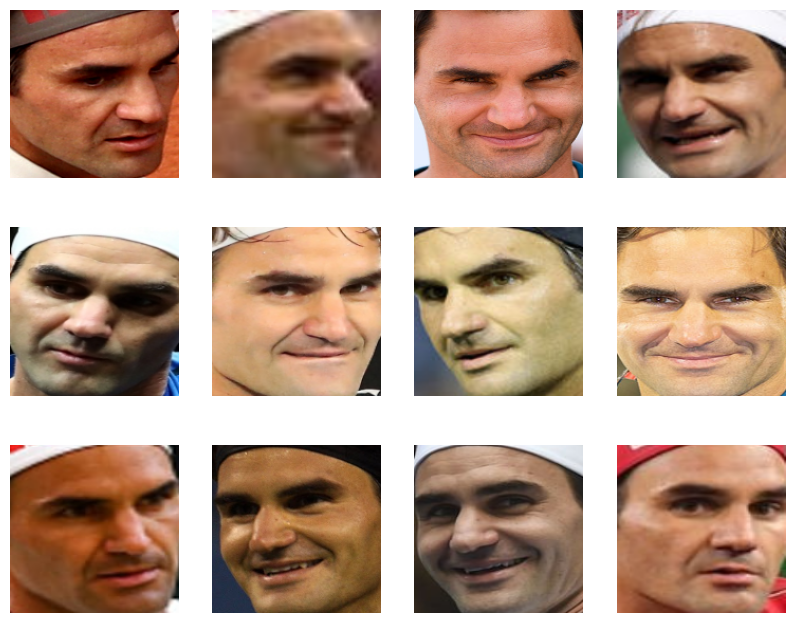


Generating embeddings...
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/

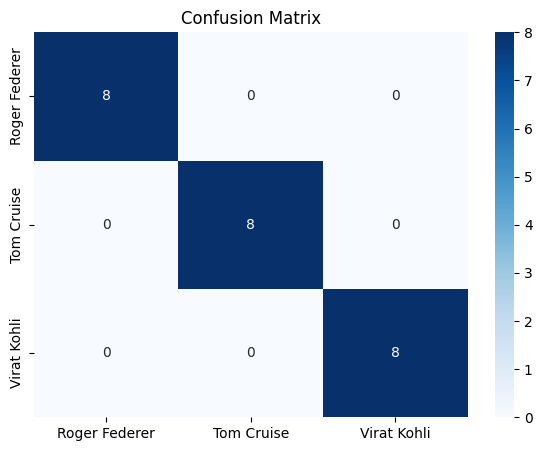

Model saved at: svm_face_model.pkl

Predicting test image:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
Prediction → Roger Federer (0.939)


In [11]:
# train_dir = "../dataset/train"
# test_img = "../dataset/test/ronaldo/ronaldo.jpg"
train_dir = "../face_img/Original Images/"
test_img = "../face_img/Faces/federer1.png"

model, encoder = run_pipeline(train_dir, test_image_path=test_img)

# 11. Real-Time Webcam Recognition

In [12]:
import cv2

detector = MTCNN()
embedder = FaceNet()

cap = cv2.VideoCapture(0)
print("Webcam started (press 'q' to quit)")

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    faces = detector.detect_faces(rgb)

    for f in faces:
        x, y, w, h = f["box"]
        x, y = abs(x), abs(y)
        face = rgb[y:y+h, x:x+w]

        face_resized = cv2.resize(face, TARGET_SIZE)
        emb = get_embedding(face_resized).reshape(1, -1)

        pred = model.predict(emb)
        name = encoder.inverse_transform(pred)[0]
        prob = np.max(model.predict_proba(emb))

        cv2.rectangle(frame, (x, y), (x+w, y+h), (0,255,0), 2)
        cv2.putText(frame, f"{name} ({prob:.2f})", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

    cv2.imshow("Real-Time Face Recognition", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Webcam started (press 'q' to quit)
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


2025-11-22 10:15:33.967550: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: INVALID_ARGUMENT: Incompatible shapes: [0,48,48,3] vs. [1,1,1,32]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

# 12. Video File Recognition

In [23]:
video_path = "../vid/s.mp4"
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Cannot open video")
else:
    print("Video started...")

while True:
    ret, frame = cap.read()
    if not ret:
        print("Video finished.")
        break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    faces = detector.detect_faces(rgb)

    for f in faces:
        x, y, w, h = f['box']
        x, y = abs(x), abs(y)
        face = rgb[y:y+h, x:x+w]

        face_resized = cv2.resize(face, TARGET_SIZE)
        emb = get_embedding(face_resized).reshape(1, -1)

        pred = model.predict(emb)
        name = encoder.inverse_transform(pred)[0]
        prob = np.max(model.predict_proba(emb))

        cv2.rectangle(frame, (x, y), (x+w, y+h), (0,255,0), 2)
        cv2.putText(frame, f"{name} ({prob:.2f})", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

    frame = cv2.resize(frame, (840, 760))
    cv2.imshow("Video Recognition", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Video started...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━

2025-11-22 10:06:12.160159: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: INVALID_ARGUMENT: Incompatible shapes: [0,48,48,3] vs. [1,1,1,32]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/s